## Extension Analysis Work (on-going)

In [3]:
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.expand_frame_repr', False)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [4]:
def joules_to_kwh(joules):
    return float(joules) / 3600000

def load_philipp_data(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/wf_data.csv') as file:
            stripped_lines = [line.rstrip().split(',') for line in file.readlines()]
            data = stripped_lines[1:]

        pkg = data[0][11]
        dram = data[0][12]
        total = data[0][13]

        processed[run] = {}
        processed[run]['pkg'] = joules_to_kwh(pkg)
        processed[run]['dram'] = joules_to_kwh(dram)
        processed[run]['total'] = joules_to_kwh(total)
    
    return processed


def load_data_totals(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        proc_data = pd.read_csv(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv', header=0)
        processed[run] = {}
        processed[run]['read'] = proc_data['read_bytes'].sum() / 1073741824  # convert from B to GiB
        processed[run]['write'] = proc_data['write_bytes'].sum() / 1073741824  # convert from B to GiB

    return processed


def load_philipp_total_energy(cluster, workflow, runs):
    processed = {}
        
    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/task_data.md') as file:
            lines = [line.strip() for line in file.readlines()]

        final = lines[-1].split(': ')[1][:-6]

        processed[run] = {}
        processed[run]['pkg'] = None
        processed[run]['dram'] = None
        processed[run]['total'] = joules_to_kwh(final)
    
    return processed

In [5]:
# Functions to parse rapl data
def load_workflow_rapl_readings(cluster, workflow):
    with open(f'nxf-experiments/{cluster}-cluster/{workflow}-runs.csv', 'r') as file:
        data = [line.strip().split(',') for line in file.readlines()]
    
    return data[1:]

gu_socket = {'rnaseq': 'both', 'chipseq': 'both', 'nanoseq': 'both', 'atacseq': 'both'}

def process_rapl_data(data, gu=False, wf=''):
    processed = {}
    run = 1

    for row in data:
        if gu:
            idle_dram_2 = float(row[14])
            total_dram_2 = float(row[11]) 
            idle_dram_1 = float(row[5])
            total_dram_1 = float(row[2])
            total_pkg_1 = float(row[1])
            total_pkg_2 = float(row[10])
            idle_pkg_1 = float(row[4])
            idle_pkg_2 = float(row[13])
            active_pkg_1 = float(row[7])
            active_pkg_2 = float(row[16])
            active_dram_1 = float(row[8])
            active_dram_2 = float(row[17])
            rapl_pkg = active_pkg_1 + active_pkg_2
            rapl_mem = active_dram_1 + active_dram_2
            rapl_total = rapl_pkg + rapl_mem
        else:
            active_pkg = float(row[7])
            total_pkg = float(row[1])
            idle_pkg = float(row[4])
            rapl_pkg = active_pkg
            idle_dram = float(row[5])
            total_dram = float(row[2])
            active_dram = float(row[8])
            rapl_mem = active_dram
            rapl_total = rapl_pkg + rapl_mem

        processed[run] = {}
        processed[run]['pkg'] = rapl_pkg
        processed[run]['dram'] = rapl_mem
        processed[run]['total'] = rapl_total
        run += 1

    return processed

In [6]:
# Functions to parse ichnos data
def load_ichnos_summary_file(summary_file):
    with open(summary_file, 'r') as file:
        raw = [line.strip() for line in file.readlines()]

    cpu = float(raw[8].split(':')[1].strip()[:-3])
    task_mem = float(raw[10].split(':')[1].strip()[:-3])
    node_mem = float(raw[16].split(':')[1].strip()[:-3])
    cpu_static = float(raw[7].split(':')[1].strip()[:-3])

    return (cpu, task_mem, node_mem, cpu_static)

def load_ichnos_data(cluster, workflow, runs, strategy, ci):
    workflow_path = f'nxf-experiments/{cluster}-cluster/{workflow}/ichnos'
    data = {}

    for run in range(1, runs + 1):
        data[run] = {}
        (cpu, task_mem, node_mem, cpu_stat) = load_ichnos_summary_file(f'{workflow_path}/{cluster}-{workflow}-{run}-{ci}-{strategy}-summary.txt')
        data[run]['pkg'] = cpu
        data[run]['mem_dyn'] = task_mem
        data[run]['mem_stat'] = node_mem 
        data[run]['total'] = cpu + task_mem
        data[run]['pkg_stat'] = cpu_stat

    return data

In [7]:
# Generic functions
def get_error(experimental, actual):
    return round((abs(experimental - actual) / actual) * 100, 2)

In [8]:
def load_nxf_trace(cluster, workflow, run):
    filepath = f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv'
    nxf_trace = pd.read_csv(filepath, header=0)
    start_ms = min(nxf_trace['start'])
    end_ms = max(nxf_trace['complete'])
    runtime = (end_ms - start_ms) / 1000 / 60  # mins
    start_day = datetime.fromtimestamp(start_ms / 1000).strftime('%Y-%m-%d')
    end_day = datetime.fromtimestamp(end_ms / 1000).strftime('%Y-%m-%d')
    nxf_trace['memory'] /= 1073741824
    print(f'{cluster} {workflow} {run} took {runtime:.0f}m on {start_day} to {end_day}')
    return (nxf_trace, runtime)

In [9]:
def plot_task_length_fig(vals, workflow):
    plt.figure(figsize=(6,2))
    plt.violinplot(vals['realtime'] / 1000 / 60, vert=False, showmedians=True, showextrema=True)
    plt.title(workflow)
    plt.xlabel('time (m)')
    plt.xlim(0,60)
    plt.show()

In [10]:
def explore_workflow(wf, wf_df, time, node_mem, run):
    avg_task_cpu_usage = np.median(wf_df['%cpu'])
    avg_task_runtime = np.median(wf_df['realtime'] / 1000)

    print(f'[{wf}]')
    print(f'no. tasks {len(wf_df)}, runtime {time:.0f}m, task {avg_task_runtime:.0f}s, cpu% {avg_task_cpu_usage:.1f}%')
    print(f'cpu [i: {run['ichnos_pkg']}, r: {run['rapl_pkg']}, e: {run['err_pkg']}]')
    print(f'mem [i: {run['i_mem_dyn']}, r: {run['rapl_mem']}, e: {run['err_mem']}]')

In [11]:
def plot_node_utilisation(wf_df, node_mem, node_cpus):
    fig, axs = plt.subplots(1, 2, sharex=True)
    fig.set_figheight(2.5)
    fig.set_figwidth(16)
    tasks_by_node = wf_df.groupby(by='hostname')
    axs[0].set_title('memory')
    axs[1].set_title('cpus')

    for group, ax, ax_cpus in zip(tasks_by_node.groups, [axs[0], axs[0], axs[0], axs[0]], [axs[1], axs[1], axs[1], axs[1]]):
        ax.set_ylabel(group)
        ax.set_ylim(0, node_mem)
        group_df = tasks_by_node.get_group(group)
        earliest = group_df['start'].min()
        latest = group_df['complete'].max()
        interval = 1 * 5 * 1000  # 15 second intervals
        bins = np.arange(earliest, latest + interval, interval)
        usage_over_time = []
        system_util_over_time = []
        task_system_utils_over_time = []

        for b in bins:
            bin_end = b + interval
            active_mask = (group_df['start'] < bin_end) & (group_df['complete'] > b) 
            total_mem = group_df.loc[active_mask, 'memory'].sum()
            cpu_usage = group_df.loc[active_mask, '%cpu']
            task_system_usage = cpu_usage / node_cpus
            system_utilisation = np.sum(task_system_usage)
            if total_mem > node_mem:
                total_mem = node_mem

            usage_over_time.append(total_mem)
            system_util_over_time.append(system_utilisation)
            task_system_utils_over_time.append(task_system_usage)

        print(group, usage_over_time)
        times = pd.to_datetime(bins, unit='ms')
        bar_width = (1 / 1440)
        free_mem = np.repeat(node_mem, len(usage_over_time)) - usage_over_time
        free_system_util = np.repeat(100, len(system_util_over_time)) - system_util_over_time
        ax.bar(times, usage_over_time, width=bar_width, color='red')
        ax.bar(times, free_mem, width=bar_width, color='green', alpha=0.3, bottom=usage_over_time)
        ax.set_ylim(0, node_mem)
        ax_cpus.bar(times, system_util_over_time, width=bar_width, color='blue')
        ax_cpus.bar(times, free_system_util, width=bar_width, color='gray', alpha=0.3, bottom=system_util_over_time)
        ax_cpus.set_ylim(0, 100)

        print('mean mem util', round(np.mean(usage_over_time), 1), '%', 'mean cpu util', round(np.mean(system_util_over_time), 1), '%')

        for task_utils, time in zip(task_system_utils_over_time, times):
            ax_cpus.scatter(x=np.repeat(time, len(task_utils)), y=task_utils, marker='x')
        break

    fig.show()

In [12]:
def analyse_workflow(wf, wf_df, time, node_mem, node_cpus, wf_run):
    explore_workflow(wf, wf_df, time, node_mem, wf_run)
    plot_task_length_fig(wf_df, wf)
    plot_node_utilisation(wf_df, node_mem, node_cpus)

In [13]:
rapl_data = {'hu': {}, 'gu': {}}
rapl_data['hu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rnaseq'), False, 'rnaseq')
rapl_data['hu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'chipseq'), False, 'chipseq')
rapl_data['hu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'atacseq'), False, 'atacseq')
rapl_data['hu']['rangeland'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rangeland'), False, 'rangeland')
rapl_data['hu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'nanoseq'), False, 'nanoseq')
rapl_data['hu']['sarek'] = process_rapl_data(load_workflow_rapl_readings('hu', 'sarek'), False, 'sarek')

rapl_data['gu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'atacseq'), True, 'atacseq')
rapl_data['gu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'chipseq'), True, 'chipseq')
rapl_data['gu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'nanoseq'), True, 'nanoseq')
rapl_data['gu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'rnaseq'), True, 'rnaseq')

ichnos_data = {'hu': {}, 'gu': {}}
ichnos_data['hu']['rnaseq'] = load_ichnos_data('hu', 'rnaseq', len(rapl_data['hu']['rnaseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['chipseq'] = load_ichnos_data('hu', 'chipseq', len(rapl_data['hu']['chipseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['atacseq'] = load_ichnos_data('hu', 'atacseq', len(rapl_data['hu']['atacseq']), 'performance_linear', 'de-2026-02-20-2026-02-24')
ichnos_data['hu']['rangeland'] = load_ichnos_data('hu', 'rangeland', len(rapl_data['hu']['rangeland']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['nanoseq'] = load_ichnos_data('hu', 'nanoseq', len(rapl_data['hu']['nanoseq']), 'performance_linear', 'de-2026-03-05-2026-03-07')
ichnos_data['hu']['sarek'] = load_ichnos_data('hu', 'sarek', len(rapl_data['hu']['sarek']), 'schedutil_linear', 'de-2026-02-07-2026-02-09')

ichnos_data['gu']['rnaseq'] = load_ichnos_data('gu', 'rnaseq', len(rapl_data['gu']['rnaseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data['gu']['atacseq'] = load_ichnos_data('gu', 'atacseq', len(rapl_data['gu']['atacseq']), 'ondemand_linear', 'gb-2026-02-27-2026-02-28')
ichnos_data['gu']['chipseq'] = load_ichnos_data('gu', 'chipseq', len(rapl_data['gu']['chipseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data['gu']['nanoseq'] = load_ichnos_data('gu', 'nanoseq', len(rapl_data['gu']['nanoseq']), 'ondemand_linear', 'gb-2026-02-10-2026-02-12')

io_data = {'hu': {}, 'gu': {}}
io_data['hu']['rnaseq'] = load_data_totals('hu', 'rnaseq', 3)
io_data['hu']['chipseq'] = load_data_totals('hu', 'chipseq', 3)
io_data['hu']['atacseq'] = load_data_totals('hu', 'atacseq', 3)
io_data['hu']['rangeland'] = load_data_totals('hu', 'rangeland', 3)
io_data['hu']['nanoseq'] = load_data_totals('hu', 'nanoseq', 3)
io_data['hu']['sarek'] = load_data_totals('hu', 'sarek', 3)

io_data['gu']['rnaseq'] = load_data_totals('gu', 'rnaseq', 3)
io_data['gu']['chipseq'] = load_data_totals('gu', 'chipseq', 3)
io_data['gu']['atacseq'] = load_data_totals('gu', 'atacseq', 3)
io_data['gu']['nanoseq'] = load_data_totals('gu', 'nanoseq', 3)

table_data = []
table_head = ['cluster', 'workflow', 'run', 'ichnos_pkg', 'rapl_pkg', 'err_pkg', 'i_mem_dyn', 'rapl_mem', 'err_mem', 'ichnos_total', 'rapl_total', 'err_total', 'i_pkg_stat', 'i_mem_stat']

for cluster in ['hu', 'gu']:
    for workflow in rapl_data[cluster].keys():
        for run in range(1, len(rapl_data[cluster][workflow].keys()) + 1):
            rapl_entry = rapl_data[cluster][workflow][run]
            rapl_pkg = rapl_entry['pkg']
            rapl_dram = rapl_entry['dram']
            ichnos_entry = ichnos_data[cluster][workflow][run]
            ichnos_pkg = ichnos_entry['pkg']
            ichnos_mem_dyn = ichnos_entry['mem_dyn']
            i_pkg_stat = ichnos_entry['pkg_stat']
            i_mem_stat = ichnos_entry['mem_stat']
            io_entry = io_data[cluster][workflow][run]
            table_data.append([cluster, workflow, run, round(ichnos_pkg, 2), round(rapl_pkg, 2), get_error(ichnos_pkg, rapl_pkg), round(ichnos_mem_dyn, 2), round(rapl_dram, 2), get_error(ichnos_mem_dyn, rapl_dram), round(ichnos_entry['total'], 2), round(rapl_entry['total'], 2), get_error(ichnos_entry['total'], rapl_entry['total']), round(i_pkg_stat, 2), round(i_mem_stat, 2)])

all_data = pd.DataFrame(table_data, columns=table_head)

In [14]:
rows_hu = all_data[all_data['cluster'] == 'hu'].reset_index()
median_rows_hu = rows_hu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)
print(median_rows_hu.sort_values(['rapl_total']))
run_nanoseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'nanoseq'].iloc[0]
run_atacseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'atacseq'].iloc[0]
run_rangeland_hu = median_rows_hu[median_rows_hu['workflow'] == 'rangeland'].iloc[0]
run_rnaseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'rnaseq'].iloc[0]
run_chipseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'chipseq'].iloc[0]
run_sarek_hu = median_rows_hu[median_rows_hu['workflow'] == 'sarek'].iloc[0]

    index cluster   workflow  run  ichnos_pkg  rapl_pkg  err_pkg  i_mem_dyn  rapl_mem  err_mem  ichnos_total  rapl_total  err_total  i_pkg_stat  i_mem_stat
13     13      hu    nanoseq    2        0.34      0.34     1.98       0.02      0.06    71.25          0.35        0.40      11.59        0.31        0.08
7       7      hu    atacseq    2        0.47      0.47     0.15       0.03      0.06    52.44          0.50        0.53       5.90        0.42        0.11
1       1      hu     rnaseq    2        1.71      1.99    14.11       0.21      0.24    14.68          1.91        2.23      14.17        1.11        0.36
10     10      hu  rangeland    2        1.56      2.00    22.29       0.24      0.25     2.80          1.80        2.25      20.14        1.15        0.37
3       3      hu    chipseq    1        3.53      4.12    14.41       0.42      0.54    21.79          3.95        4.66      15.27        2.30        0.74
17     17      hu      sarek    3        3.83      4.40    12.85

In [15]:
rows_gu = all_data[all_data['cluster'] == 'gu'].reset_index()
median_rows_gu = rows_gu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)
print(median_rows_gu.sort_values(['rapl_total']))
run_nanoseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'nanoseq'].iloc[0]
run_atacseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'atacseq'].iloc[0]
run_rnaseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'rnaseq'].iloc[0]
run_chipseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'chipseq'].iloc[0]

    index cluster workflow  run  ichnos_pkg  rapl_pkg  err_pkg  i_mem_dyn  rapl_mem  err_mem  ichnos_total  rapl_total  err_total  i_pkg_stat  i_mem_stat
6      24      gu  nanoseq    1        0.58      0.58     0.91       0.12      0.12     3.46          0.70        0.70       0.13        0.51        0.20
2      20      gu  atacseq    3        0.91      0.90     1.40       0.20      0.17    17.17          1.12        1.08       3.94        0.80        0.31
10     28      gu   rnaseq    2        0.99      0.96     3.06       0.21      0.18    13.33          1.20        1.15       4.69        0.89        0.34
4      22      gu  chipseq    2        1.29      1.31     1.69       0.28      0.23    21.12          1.57        1.54       1.73        1.13        0.42


In [16]:
hu_nanoseq, hu_nanoseq_time = load_nxf_trace('hu', 'nanoseq', 2)
hu_atacseq, hu_atacseq_time = load_nxf_trace('hu', 'atacseq', 3)
hu_rangeland, hu_rangeland_time = load_nxf_trace('hu', 'rangeland', 1)
hu_rnaseq, hu_rnaseq_time = load_nxf_trace('hu', 'rnaseq', 2)
hu_chipseq, hu_chipseq_time = load_nxf_trace('hu', 'chipseq', 2)
hu_sarek, hu_sarek_time = load_nxf_trace('hu', 'sarek', 2)

hu nanoseq 2 took 90m on 2026-03-06 to 2026-03-06
hu atacseq 3 took 110m on 2026-02-23 to 2026-02-23
hu rangeland 1 took 253m on 2025-11-22 to 2025-11-23
hu rnaseq 2 took 251m on 2025-11-18 to 2025-11-18
hu chipseq 2 took 601m on 2025-11-19 to 2025-11-20
hu sarek 2 took 514m on 2026-02-08 to 2026-02-08


In [17]:
gu_nanoseq, gu_nanoseq_time = load_nxf_trace('gu', 'nanoseq', 1)
gu_atacseq, gu_atacseq_time = load_nxf_trace('gu', 'atacseq', 3)
gu_rnaseq, gu_rnaseq_time = load_nxf_trace('gu', 'rnaseq', 1)
gu_chipseq, gu_chipseq_time = load_nxf_trace('gu', 'chipseq', 3)

gu nanoseq 1 took 217m on 2026-02-11 to 2026-02-11
gu atacseq 3 took 251m on 2026-02-28 to 2026-02-28
gu rnaseq 1 took 253m on 2026-01-29 to 2026-01-29
gu chipseq 3 took 311m on 2026-01-29 to 2026-01-29


[nanoseq]
no. tasks 92, runtime 90m, task 24s, cpu% 123.5%
cpu [i: 0.34, r: 0.34, e: 1.98]
mem [i: 0.02, r: 0.06, e: 71.25]


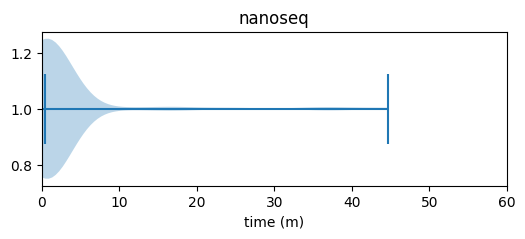

hu-worker-c40 [42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 0.0, 54.0, 54.0, 66.0, 66.0, 66.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 54.0, 54.0, 96.0, 96.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42

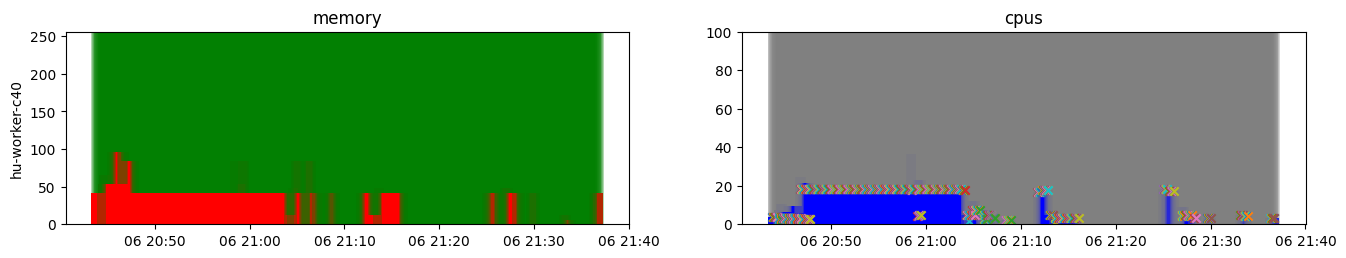

In [18]:
analyse_workflow('nanoseq', hu_nanoseq, hu_nanoseq_time, 256, 32, run_nanoseq_hu)

[atacseq]
no. tasks 268, runtime 110m, task 28s, cpu% 127.0%
cpu [i: 0.47, r: 0.47, e: 0.15]
mem [i: 0.03, r: 0.06, e: 52.44]


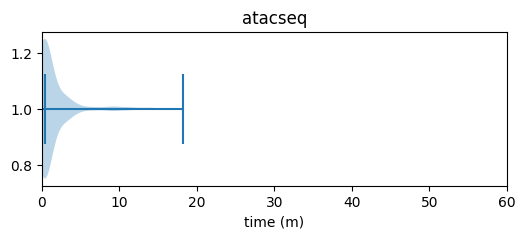

hu-worker-c40 [72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 72.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 72.0, 72.0, 72.0, 72.0, 0.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0

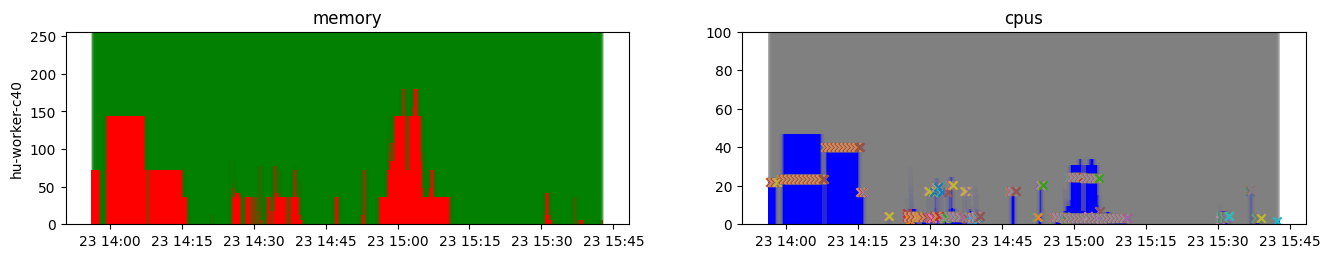

In [19]:
analyse_workflow('atacseq', hu_atacseq, hu_atacseq_time, 256, 32, run_atacseq_hu)

[rangeland]
no. tasks 3154, runtime 253m, task 22s, cpu% 100.6%
cpu [i: 1.56, r: 2.0, e: 22.29]
mem [i: 0.24, r: 0.25, e: 2.8]


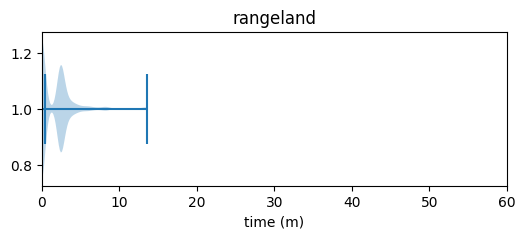

hu-worker-c40 [6.0, 0.0, 66.0, 0.0, 114.0, 0.0, 96.0, 84.0, 0.0, 0.0, 126.0, 78.0, 42.0, 42.0, 36.0, 42.0, 36.0, 36.0, 36.0, 42.0, 36.0, 36.0, 36.0, 36.0, 36.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 36.0, 36.0, 36.0, 36.0, 0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 0.0, 6.0, 0.0, 90.0, 48.0, 66.0, 60.0, 72.0, 72.0, 78.0, 78.0, 72.0, 78.0, 84.0, 84.0, 90.0, 90.0, 78.0, 90.0, 96.0, 96.0, 114.0, 108.0, 120.0, 120.0, 132.0, 126.0, 126.0, 132.0, 144.0, 150.0, 162.0, 150.0, 156.0, 150.0, 144.0, 144.0, 150.0, 150.0, 174.0, 162.0, 168.0, 168.0, 162.0, 162.0, 162.0, 168.0, 192.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 150.0, 156.0, 150.0, 168.0, 156.0, 168.0, 162.0, 150.0, 156.0, 168.0, 162.0, 174.0, 168.0, 168.0, 168.0, 168.0, 162.0, 174.0, 162.0, 168.0, 186.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 216.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 

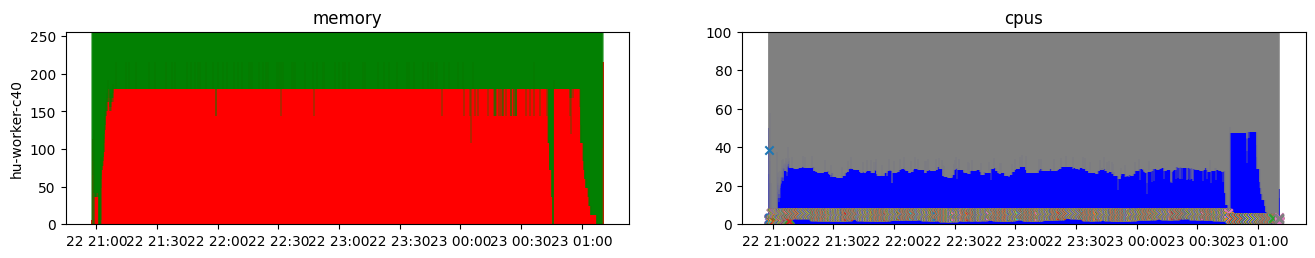

In [20]:
analyse_workflow('rangeland', hu_rangeland, hu_rangeland_time, 256, 32, run_rangeland_hu)

[rnaseq]
no. tasks 1269, runtime 251m, task 71s, cpu% 111.3%
cpu [i: 1.71, r: 1.99, e: 14.11]
mem [i: 0.21, r: 0.24, e: 14.68]


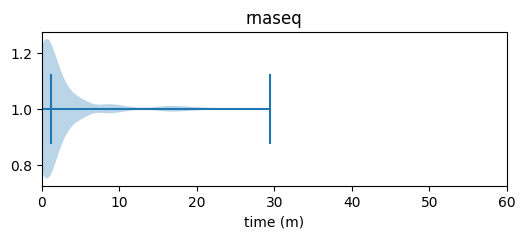

hu-worker-c40 [180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 216.0, 180.0, 144.0, 144.0, 144.0, 180.0, 144.0, 180.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 216.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 144.0, 144.0, 144.0, 168.0, 168.0, 168.0, 168.0, 168.0, 168.0, 168.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 192.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0

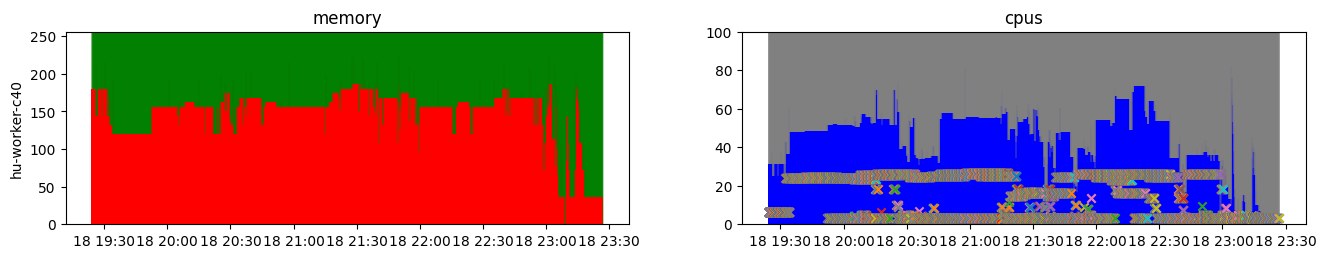

In [21]:
analyse_workflow('rnaseq', hu_rnaseq, hu_rnaseq_time, 256, 32, run_rnaseq_hu)

[chipseq]
no. tasks 3538, runtime 601m, task 31s, cpu% 128.7%
cpu [i: 3.53, r: 4.12, e: 14.41]
mem [i: 0.42, r: 0.54, e: 21.79]


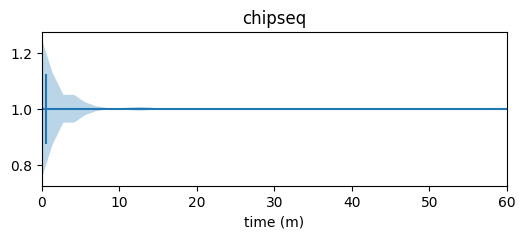

hu-worker-c40 [12.0, 156.0, 156.0, 162.0, 192.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 216.0, 180.0, 180.0, 144.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 144.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 144.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 252.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 144.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0,

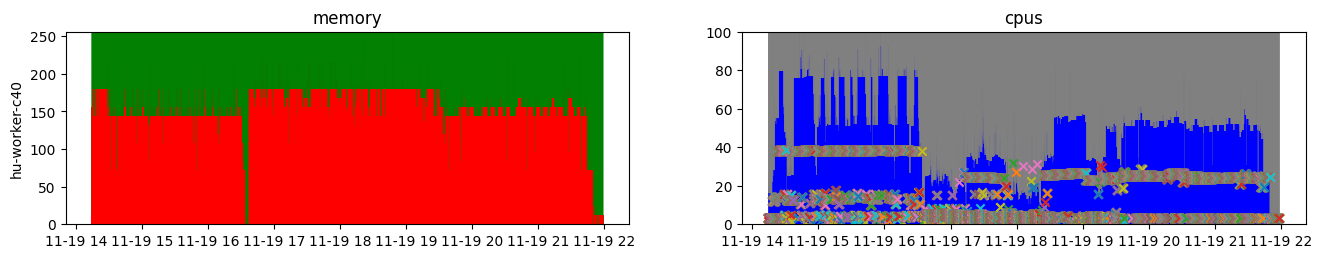

In [22]:
analyse_workflow('chipseq', hu_chipseq, hu_chipseq_time, 256, 32, run_chipseq_hu)

[sarek]
no. tasks 7427, runtime 514m, task 56s, cpu% 144.7%
cpu [i: 3.83, r: 4.4, e: 12.85]
mem [i: 0.22, r: 0.62, e: 64.78]


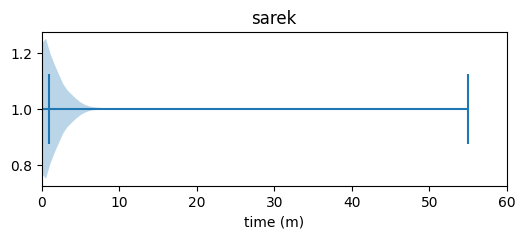

hu-worker-c40 [14.0, 13.0, 12.0, 15.0, 15.0, 15.0, 12.0, 12.0, 12.0, 13.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 16.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 16.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 24.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 16.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 16.0, 12.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 12.0, 8.0, 8.0, 8.0, 8.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0,

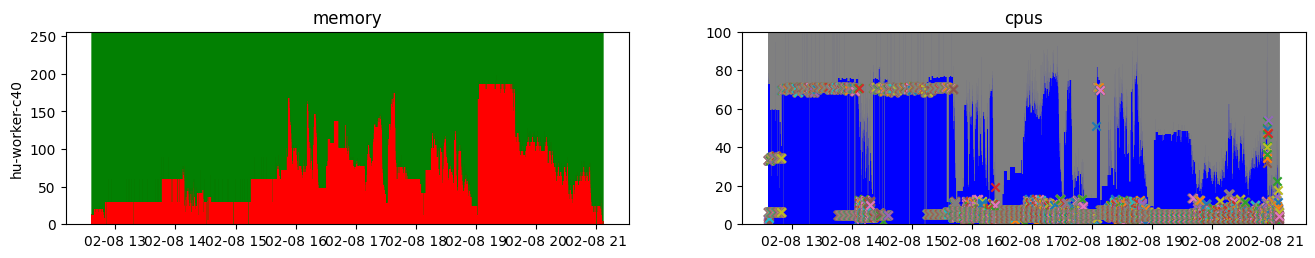

In [23]:
analyse_workflow('sarek', hu_sarek, hu_sarek_time, 256, 32, run_sarek_hu)

[nanoseq]
no. tasks 92, runtime 90m, task 24s, cpu% 123.5%
cpu [i: 0.34, r: 0.34, e: 1.98]
mem [i: 0.02, r: 0.06, e: 71.25]


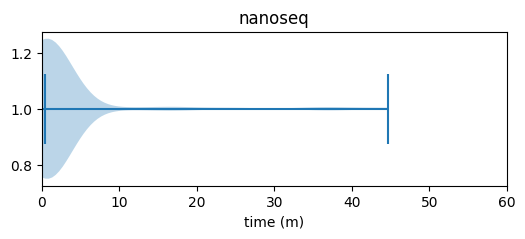

hu-worker-c40 [42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 0.0, 54.0, 54.0, 64, 64, 64, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 54.0, 54.0, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42

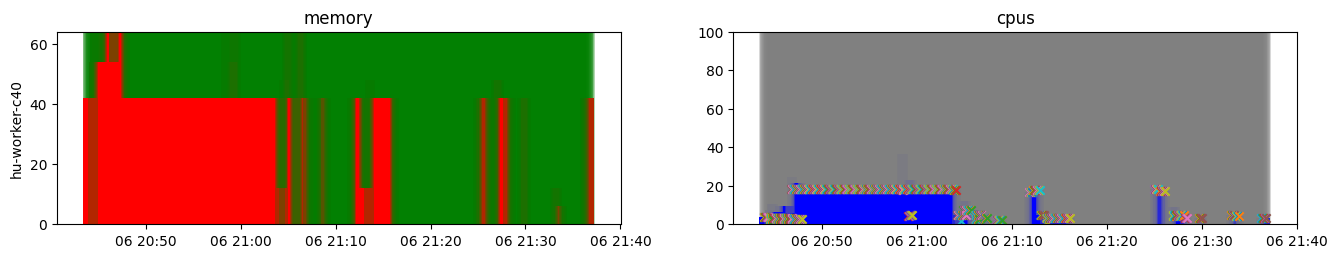

In [24]:
analyse_workflow('nanoseq', hu_nanoseq, hu_nanoseq_time, 64, 32, run_nanoseq_hu)

[atacseq]
no. tasks 268, runtime 251m, task 57s, cpu% 120.0%
cpu [i: 0.91, r: 0.9, e: 1.4]
mem [i: 0.2, r: 0.17, e: 17.17]


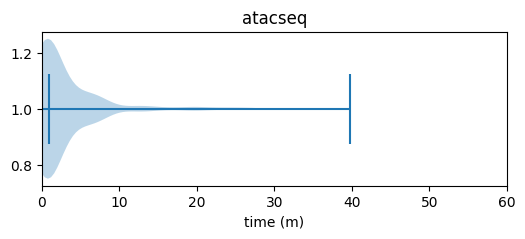

gpgnode-13 [36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 0.0, 6.0, 6.0, 6.0, 6.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 3

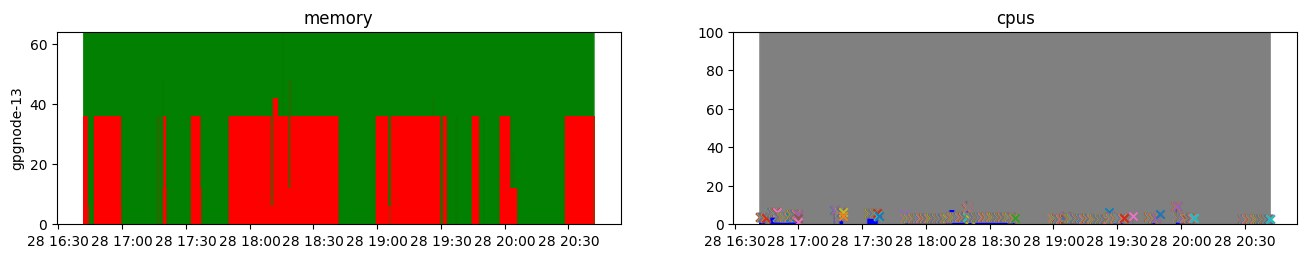

In [25]:
analyse_workflow('atacseq', gu_atacseq, gu_atacseq_time, 64, 32, run_atacseq_gu)

[rnaseq]
no. tasks 231, runtime 253m, task 125s, cpu% 108.1%
cpu [i: 0.99, r: 0.96, e: 3.06]
mem [i: 0.21, r: 0.18, e: 13.33]


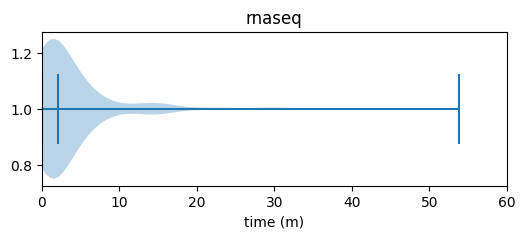

gpgnode-13 [12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

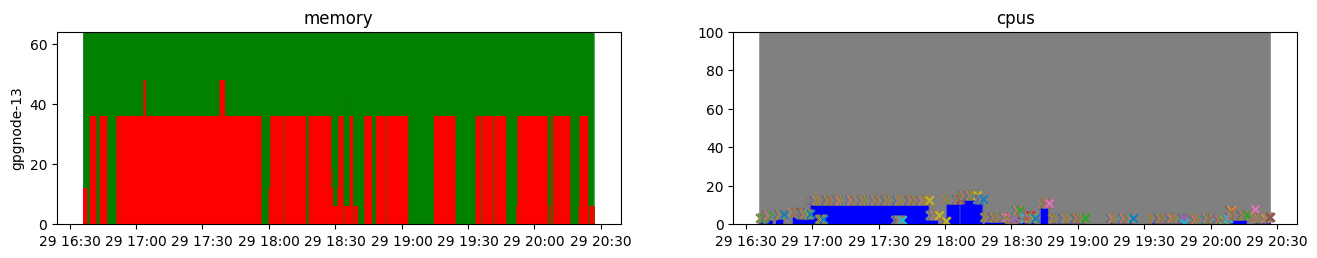

In [26]:
analyse_workflow('rnaseq', gu_rnaseq, gu_rnaseq_time, 64, 32, run_rnaseq_gu)

[chipseq]
no. tasks 314, runtime 311m, task 80s, cpu% 121.0%
cpu [i: 1.29, r: 1.31, e: 1.69]
mem [i: 0.28, r: 0.23, e: 21.12]


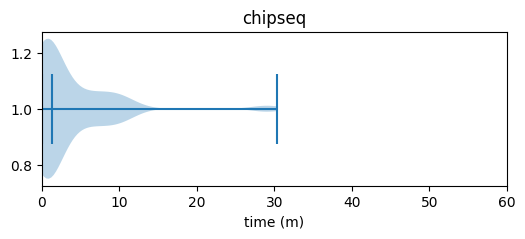

gpgnode-13 [6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.

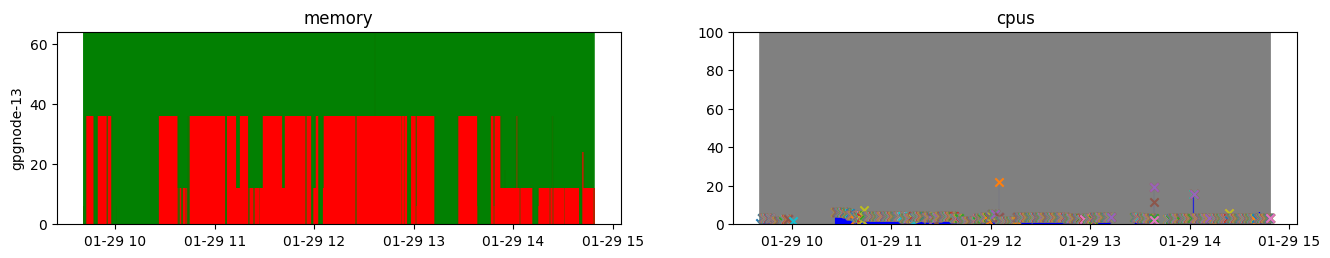

In [27]:
analyse_workflow('chipseq', gu_chipseq, gu_chipseq_time, 64, 32, run_chipseq_gu)

observations
- cpu is generally estimated well, if we have an error, we tend to under-estimate
  - worst case was rangeland, which has shortest avg. task length, which leads to high CPU utilisation, but is harder to capture full energy consumption
- memory is more varied
  - if we have gaps where some nodes are not utilised, but one node still active, we underestimate since RAPL captures the static consumption (represent with a graph?)
  - other times, we over estimate where the memory utilisation is high, i.e. assigned to tasks, lots over the same period, leading to high utilisation and therefore, energy consumption

In [28]:
# todo -- take functions from eval.ipynb
# print the graphs (only the governors we are interested in), for the workflow runs with the:
# - 4x GPG nodes
# - 4x HU nodes

In [29]:
def load_nfco2fp_summary(cluster, workflow, run):
    filepath = f'nf-co2footprint/output/{cluster}-cluster/co2fp-summary-{workflow}-{run}.txt'
    with open(filepath, 'r') as file:
        data = file.readlines()

    energy_val, energy_unit = data[2].split(':')[1].strip().split(' ')
    if energy_unit == 'Wh':
        return float(energy_val) / 1000
    elif energy_unit == 'kWh':
        return float(energy_val)

In [30]:
# compare ichnos with nf-co2footprint plugin

# print all of ichnos results
print('hu-cluster')
compare_hu = rows_hu.copy().drop(['cluster', 'err_pkg', 'err_mem', 'err_total'], axis=1)
print(compare_hu.sort_values(['workflow', 'run']))

hu-cluster
    index   workflow  run  ichnos_pkg  rapl_pkg  i_mem_dyn  rapl_mem  ichnos_total  rapl_total  i_pkg_stat  i_mem_stat
6       6    atacseq    1        0.46      0.45       0.03      0.06          0.49        0.51        0.41        0.11
7       7    atacseq    2        0.47      0.47       0.03      0.06          0.50        0.53        0.42        0.11
8       8    atacseq    3        0.48      0.47       0.03      0.06          0.51        0.54        0.43        0.11
3       3    chipseq    1        3.53      4.12       0.42      0.54          3.95        4.66        2.30        0.74
4       4    chipseq    2        3.51      4.11       0.42      0.55          3.94        4.66        2.29        0.74
5       5    chipseq    3        3.51      4.11       0.42      0.54          3.93        4.65        2.29        0.74
12     12    nanoseq    1        0.31      0.31       0.02      0.05          0.32        0.36        0.27        0.07
13     13    nanoseq    2        0.34

In [31]:
print('gu-cluster')
gu_copy = rows_gu.copy()
heads = ['wf', 'run', 'ichnos', 'rapl', 'nfco2', 'dyn_only', 'stat_only']
data = []

for _, row in gu_copy.iterrows():
    wf = row['workflow']
    run = row['run']
    i_total = row['ichnos_total']
    r_total = row['rapl_total']
    nfco2_dynamic = load_nfco2fp_summary('gu', wf, run)
    static_energy = row['i_pkg_stat']
    nfco2_total = round(nfco2_dynamic + static_energy, 2)
    data.append([wf, run, i_total, r_total, nfco2_total, nfco2_dynamic, static_energy])

print(tabulate(data, headers=heads))

gu-cluster
wf         run    ichnos    rapl    nfco2    dyn_only    stat_only
-------  -----  --------  ------  -------  ----------  -----------
atacseq      1      1.12    1.07     1.32     0.50589         0.81
atacseq      2      1.11    1.09     1.31     0.50637         0.8
atacseq      3      1.12    1.08     1.31     0.50524         0.8
chipseq      1      1.58    1.53     1.91     0.76763         1.14
chipseq      2      1.57    1.54     1.9      0.76534         1.13
chipseq      3      1.59    1.54     1.92     0.76987         1.15
nanoseq      1      0.7     0.7      0.83     0.31673         0.51
nanoseq      2      0.67    0.68     0.81     0.31544         0.49
nanoseq      3      0.69    0.7      0.83     0.31669         0.51
rnaseq       1      1.18    1.16     1.38     0.49796         0.88
rnaseq       2      1.2     1.15     1.39     0.50258         0.89
rnaseq       3      1.2     1.14     1.39     0.49941         0.89


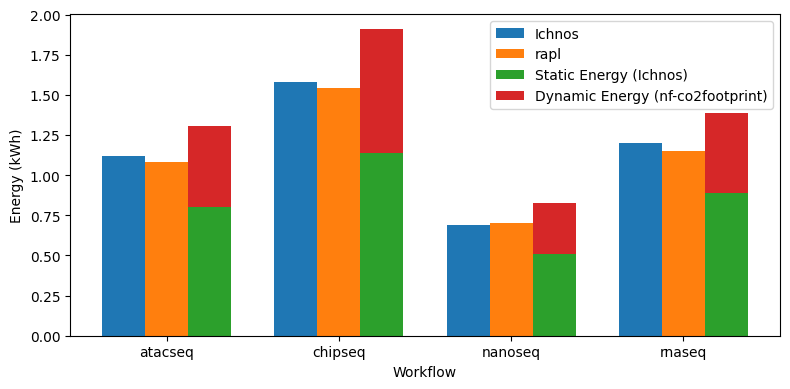

In [ ]:
gu_baseline_comp = pd.DataFrame(data, columns=heads)
gu_baseline_grouped = gu_baseline_comp.groupby('wf').median()

wfs = gu_baseline_grouped.index
x = np.arange(4)
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width, gu_baseline_grouped['ichnos'].values, width, label='Ichnos')
ax.bar(x, gu_baseline_grouped['rapl'].values, width, label='rapl')
ax.bar(x + width, gu_baseline_grouped['stat_only'].values, width, label='Static Energy (Ichnos)')
ax.bar(x + width, gu_baseline_grouped['dyn_only'].values, width, bottom=gu_baseline_grouped['stat_only'].values, label='Dynamic Energy (nf-co2footprint)')

ax.set_ylabel('Energy (kWh)')
ax.set_xticks(x, wfs)
ax.set_xlabel('Workflow')
ax.legend()

plt.tight_layout()
plt.show()

# question: do we want to separate ichnos static and dynamic (same colour for ichnos static) or just compare 'ichnos' as a value